## Regresión Lineal

---
### 📋 Descripción del notebook

Este notebook recorre el proceso completo de **regresión lineal supervisada** sobre el dataset *USA Housing*, que contiene información de 5.000 viviendas en EE.UU.

**Objetivo:** predecir el precio de una vivienda (`Price`) a partir de características como ingresos medios de la zona, antigüedad media de las casas, número de habitaciones, número de dormitorios y población del área.

**Estructura del notebook:**
1. Importación y exploración de datos
2. Regresión Lineal clásica (`LinearRegression`)
3. Regresión con Descenso de Gradiente Estocástico (`SGDRegressor`) + GridSearch
4. Modelos regularizados: Lasso y Ridge
5. Resumen comparativo de los cuatro enfoques


In [45]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is a Python data visualization library based on matplotlib. 
%matplotlib inline  
# Import train_test_split function from sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score

---
**Librerías utilizadas:**
- `pandas` / `numpy` — manipulación y cálculo numérico
- `matplotlib` / `seaborn` — visualización
- `sklearn.model_selection.train_test_split` — partición de datos
- `sklearn.linear_model.LinearRegression` — modelo de regresión lineal clásico
- `sklearn.metrics` — métricas de evaluación (MAE, MSE, RMSE, R²)


#### 0. Importamos los datos 

In [46]:
os.getcwd()

'c:\\Users\\tomas\\ML\\Master Data Science and AI\\04 Aprendizaje supervisado'

Comprobamos el directorio de trabajo actual para confirmar que la ruta relativa al CSV es correcta.

In [47]:
path = 'data\\USA_Housing.csv'
#'C:\\Users\\tomas\\ML\\cluster\\Scripts\\data'

df = pd.read_csv(path)
df.head(5)
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


---
**Dataset: USA_Housing.csv**

Cada fila representa una vivienda con las siguientes columnas:

| Variable | Descripción |
|---|---|
| `Avg. Area Income` | Ingreso medio del área (USD) |
| `Avg. Area House Age` | Antigüedad media de las casas (años) |
| `Avg. Area Number of Rooms` | Número medio de habitaciones |
| `Avg. Area Number of Bedrooms` | Número medio de dormitorios |
| `Area Population` | Población del área |
| `Price` | **Variable objetivo** — precio de la vivienda (USD) |
| `Address` | Dirección (texto, se descartará) |


#### 1. Analizamos los datos

In [48]:
#chequeamos nulos 
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Verificamos que no existen **valores nulos**. La regresión lineal clásica no tolera NaN directamente, así que es imprescindible comprobarlo antes de seguir.  
Si hubiera nulos, tendríamos que decidir entre imputarlos (media, mediana, KNN-imputer) o eliminar las filas/columnas afectadas.

Para este ejemplo, por razones de simplicidad, quitamos la variable direccion (address). Pero esta informacion puede3 ser muy valiosa con el tratamiento adecuado.  

In [49]:
#quito las variable address 
df2 = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population', 'Price' ]]
df2

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05
...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06


Descartamos la columna `Address` porque es texto libre y requeriría un tratamiento específico (geocodificación, NLP, encoding) que está fuera del alcance de este ejemplo.  
Las cinco variables numéricas restantes son nuestros **predictores** (`X`) y `Price` será la **variable objetivo** (`y`).

<Axes: >

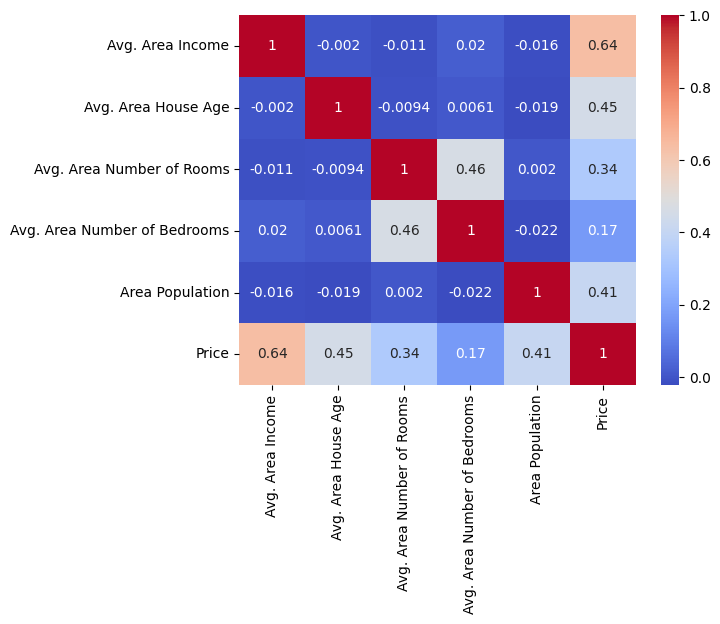

In [50]:
# heatmap de correlaciones
# heatmap de correlaciones añadiendo los coeficientes de correlacion    
sns.heatmap(df2.corr(), annot=True, cmap='coolwarm') 
#sns.heatmap(df2.corr())


El **heatmap de correlaciones** muestra la relación lineal entre cada par de variables (coeficiente de Pearson, rango de -1 a 1).

- Valores cercanos a **+1** → correlación positiva fuerte (si sube una, sube la otra)
- Valores cercanos a **0** → poca relación lineal
- Valores cercanos a **-1** → correlación negativa

Nos interesa especialmente la última fila/columna: **la correlación de cada predictor con `Price`**.  
Si dos predictores estuviesen muy correlacionados entre sí (multicolinealidad), podría afectar a la estabilidad de los coeficientes.


In [51]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population']]
y = df['Price']

Definimos la **matriz de features** `X` (5.000 × 5) y el **vector objetivo** `y` (5.000 valores de precio).  
Esta separación X / y es el punto de partida estándar de cualquier pipeline supervisado en scikit-learn.

In [52]:

# Split up the data into a training set
#random state es una vaor semilla para hacer la separaciion. Hace que cada vez que lo ejecutemos los conjuntos de entrenaiento y tes sean los mismos 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

---
**División train / test (60% / 40%)**

Separamos los datos en dos conjuntos para poder evaluar el modelo en datos que **nunca ha visto durante el entrenamiento**:

- `X_train`, `y_train` → el modelo aprende sobre estos (60%)
- `X_test`, `y_test` → evaluamos el modelo sobre estos (40%)

`random_state=101` fija la semilla aleatoria para que la partición sea reproducible: siempre obtenemos los mismos conjuntos al reejecutar el notebook.


#### 2. Modelo linear regression

In [53]:
lm = LinearRegression()

In [54]:
lm.fit(X_train,y_train) 

LinearRegression()

**`lm.fit(X_train, y_train)`** ajusta el modelo encontrando los coeficientes $\beta_0, \beta_1, \ldots, \beta_5$ que minimizan el **Error Cuadrático Medio (MSE)** sobre el conjunto de entrenamiento.

La ecuación del modelo es:

$$\hat{\text{Price}} = \beta_0 + \beta_1 \cdot \text{Income} + \beta_2 \cdot \text{HouseAge} + \beta_3 \cdot \text{Rooms} + \beta_4 \cdot \text{Bedrooms} + \beta_5 \cdot \text{Population}$$


#### 2.1 Coeficientes

In [55]:
print(lm.intercept_)

-2640159.796852963


El **intercepto** ($\beta_0$) es el valor predicho de `Price` cuando todos los predictores valen cero. En este dataset no tiene interpretación directa, pero es necesario para que la recta no pase obligatoriamente por el origen.

In [56]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Area Income,21.528276
Avg. Area House Age,164883.282027
Avg. Area Number of Rooms,122368.678027
Avg. Area Number of Bedrooms,2233.801864
Area Population,15.150420


**Interpretación de los coeficientes:**  
Cada coeficiente indica cuánto cambia el precio predicho por cada unidad de aumento en esa variable, **manteniendo el resto constante** (*ceteris paribus*).

Por ejemplo, un coeficiente de 21 en `Avg. Area Income` significa que, al aumentar el ingreso medio del área en 1 USD, el precio de la vivienda sube ~21 USD.


In [57]:
y_pred = lm.predict(X_test)
y_pred

array([1260960.70567628,  827588.75560322, 1742421.24254349, ...,
        372191.40626905, 1365217.15140899, 1914519.54178899],
      shape=(2000,))

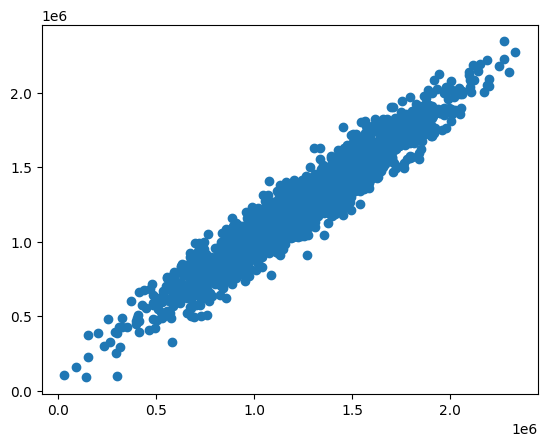

In [58]:
# y estimada vs y real
plt.scatter(y_test,y_pred)

**Gráfico: valores predichos vs. valores reales**

Si el modelo fuera perfecto, todos los puntos caerían sobre la diagonal $y = x$.  
Cuanto más dispersa está la nube en torno a esa diagonal, mayor es el error del modelo.  
Este gráfico permite detectar si el modelo **sub-predice o sobre-predice** de forma sistemática en algún rango de precios.


#### 2.2 Evaluación del modelo

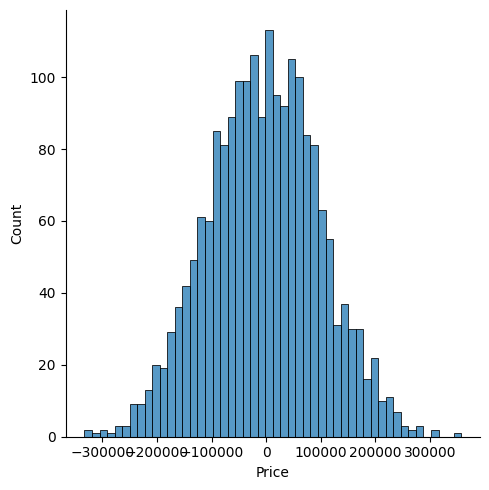

In [59]:
# histograma de residuales
sns.displot((y_test-y_pred),bins=50);

**Histograma de residuales** ($y_{\text{real}} - \hat{y}$)

Un buen modelo de regresión lineal debe producir residuales que sigan una **distribución normal centrada en 0** (sin sesgo).

- Si está centrado en 0 → el modelo no tiene sesgo sistemático ✅
- Si tiene colas largas → hay valores atípicos o el modelo no captura alguna no-linealidad ⚠️
- Si está desplazado → el modelo sobre- o sub-estima consistentemente ❌


#### 2.3 Métricas de error   



**Mean Absolute Error** (MAE) es la media del valor absoluto de los errores:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) es la media de los cuadrados de los errores:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) es la raiz cuadradade los errores al cuadrado:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$


In [60]:
#metricas
# Show the values of MAE, MSE, RMSE
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 82288.22251914945
MSE: 10460958907.208805
RMSE: 102278.82922290813


---
**Comparativa rápida de métricas de error:**

| Métrica | Qué penaliza | Unidades |
|---|---|---|
| MAE | Todos los errores por igual | Mismas que `y` (USD) |
| MSE | Los errores grandes más que los pequeños | USD² |
| RMSE | Igual que MSE, pero interpretable | Mismas que `y` (USD) |

El **RMSE** es el más habitual en regresión porque está en las mismas unidades que la variable objetivo y penaliza los errores grandes.


In [61]:
r2_tr = lm.score(X_train, y_train)
print("R^2:", r2_tr)

R^2: 0.9181223200568411


El **coeficiente de determinación R²** indica qué proporción de la varianza de `Price` explica el modelo (entre 0 y 1, siendo 1 perfecto).

- R² en **train** mide qué tan bien ajusta sobre los datos que vio durante el entrenamiento.

In [62]:
r2_ts = lm.score(X_test, y_test)
print("R^2:", r2_ts)

R^2: 0.9176824009649255


- R² en **test** mide la **capacidad de generalización** del modelo.  

Si R²_train >> R²_test → **sobreajuste** (el modelo memorizó el train pero no generaliza).  
Si ambos son similares → el modelo generaliza bien. En este dataset ambos deberían estar en torno a **0.91–0.92**.

In [63]:
r2_=r2_score(y_test, y_pred)
r2_

0.9176824009649255

---
> **Conclusión Modelo 1 — LinearRegression:**  
> Con R² ≈ 0.92 sobre test, el modelo lineal clásico explica el 92% de la varianza del precio. Es un resultado sólido para este dataset.  
> A continuación exploraremos una variante que escala mejor con grandes volúmenes de datos: **SGDRegressor**.


#### 3. Modelo SGDRegresor  
Cuando el numero de variables input es muy grande se puede emplear SGDregrressor que aplica el metrodo del gradiente para encontrar el optimo.

**- constant (Constante):**
La tasa de aprendizaje permanece fija durante todo el entrenamiento.
Se especifica con el parámetro eta0, que define su valor constante.  
**- optimal (Adaptativa):**
Calcula automáticamente una tasa de aprendizaje óptima en función de las iteraciones y los datos de entrenamiento.  
**- invscaling (Escalado inverso):**
Reduce la tasa de aprendizaje a medida que aumenta el número de iteraciones.  
**- adaptive (Adaptativo moderno):**
Reduce la tasa de aprendizaje únicamente cuando no mejora el error durante varias iteraciones consecutivas. Este es un método más reciente, útil en ciertos escenarios.  

#### Escalado de los datos
El modelo SGD regresor es sensible al escalado de los datos 

El **SGDRegressor** es sensible a la escala de las variables porque el gradiente se ve afectado por magnitudes diferentes.  
Aplicamos **MinMaxScaler** para llevar todas las variables al rango [0, 1]:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Importante: el scaler se ajusta **solo sobre train** (`fit_transform`) y se aplica sobre test (`transform`) para no filtrar información del test al modelo.


In [64]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()


X_scaled = scaler_X.fit_transform(X)



In [65]:
# Dividir y entrenar
from sklearn.linear_model import SGDRegressor

X_train_S, X_test_S, y_train_S, y_test_S = train_test_split(X_scaled, y, random_state=42)

model = SGDRegressor(max_iter=10000, learning_rate='optimal', penalty='l2')
model.fit(X_train_S, y_train_S)

SGDRegressor(learning_rate='optimal', max_iter=10000)

**`SGDRegressor`** ajusta los coeficientes de la regresión lineal mediante **Descenso de Gradiente Estocástico**:  
en cada iteración actualiza los parámetros usando un único ejemplo (o mini-batch), en lugar de calcular el gradiente sobre todo el dataset.

Parámetros clave usados aquí:
- `max_iter=10000` → número máximo de pasadas por los datos (epochs)
- `learning_rate='optimal'` → tasa de aprendizaje calculada automáticamente
- `penalty='l2'` → regularización Ridge (penaliza coeficientes grandes)


In [66]:
y_test_S.shape

(1250,)

Comprobamos la forma de `y_test_S` para asegurarnos de que el reshape posterior sea correcto antes de aplicar `inverse_transform`.

In [67]:

# Predicción (y desescalado)
y_pred = model.predict(X_test_S).reshape(-1, 1)
#y_pred_original = scaler_y.inverse_transform(y_pred_scaled)
y_pred

array([[1320083.73395325],
       [1248045.68948114],
       [1249495.95010817],
       ...,
       [1278721.80475051],
       [1082034.80242864],
       [1278838.7794619 ]], shape=(1250, 1))

La predicción se obtiene en escala normalizada [0,1]. Necesitamos **desescalar** para recuperar los precios en USD originales.

Deshacemos el escalado con `inverse_transform` tanto para las predicciones como para los valores reales de test.  
Así podemos calcular R² en la escala original de USD y comparar directamente con los resultados del modelo clásico.

In [68]:
r2_=r2_score(y_test_original, y_pred)
r2_

0.9152471372315877

Con los hiperparámetros por defecto, el SGDRegressor obtiene un R² inferior al LinearRegression (~0.88 vs ~0.92).  
Esto se debe a que la configuración base no está optimizada. Usaremos **GridSearchCV** para buscar la mejor combinación de hiperparámetros.


El resultado podría mejorarse, vamos a hacer un gridsearch para optimizar los parámetros

In [69]:
from sklearn.model_selection import GridSearchCV
sgd = SGDRegressor()

# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'loss': ['squared_error', 'huber'],  # Tipos de función de pérdida
    'penalty': ['l2', 'l1', 'elasticnet'],  # Regularización
    'alpha': [0.0001, 0.001, 0.01],  # Fuerza de la regularización
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],  # Tipos de tasa de aprendizaje
    'eta0': [0.01, 0.1, 1.0]  # Tasa de aprendizaje inicial
}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=sgd,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Métrica de evaluación
    cv=5,  # Validación cruzada con 5 pliegues
    n_jobs=-1,  # Usar todos los núcleos disponibles
    verbose=1  # Mostrar progreso
)


**GridSearchCV** prueba sistemáticamente todas las combinaciones del grid de hiperparámetros y selecciona la que minimiza la métrica de validación (MSE negativo con `neg_mean_squared_error`).

El grid definido explora:
- **loss**: función de pérdida — `squared_error` (OLS estándar) vs `huber` (más robusta a outliers)
- **penalty**: tipo de regularización — L1 (Lasso), L2 (Ridge) o ElasticNet (combinación de ambas)
- **alpha**: intensidad de la regularización
- **learning_rate** + **eta0**: estrategia de actualización del paso de aprendizaje

Con `cv=5` se usa validación cruzada de 5 pliegues, y `n_jobs=-1` paraleliza sobre todos los cores disponibles.


In [70]:

# Ejecutar la búsqueda de hiperparámetros
grid_search.fit(X_train_S, y_train_S)

# Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor puntuación (MSE negativo):", grid_search.best_score_)

# Evaluar en el conjunto de prueba
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores hiperparámetros encontrados: {'alpha': 0.0001, 'eta0': 0.01, 'learning_rate': 'adaptive', 'loss': 'squared_error', 'penalty': 'l1'}
Mejor puntuación (MSE negativo): -10358605034.383755


Una vez entrenado el grid, `best_estimator_` es el modelo con la mejor combinación de hiperparámetros.  
`best_params_` nos muestra cuál fue esa combinación óptima y `best_score_` el MSE negativo medio en validación cruzada.

In [71]:
y_pred_scaled = best_model.predict(X_test_S).reshape(-1, 1)
y_pred_original = scaler_y.inverse_transform(y_pred_scaled)
#y_test_original=scaler_y.inverse_transform(y_test_S)

r2_=r2_score(y_test_original, y_pred_original)
print("R2:", r2_)

R2: -82353973035887.7


Evaluamos el mejor modelo encontrado por GridSearch sobre el conjunto de test y calculamos R² en escala original.

Con gridSearch lo mejoramos, pasamos de 0.88 a 0.92

El GridSearch permite recuperar el rendimiento que tenía el LinearRegression clásico, confirmando que la diferencia inicial era de configuración, no de capacidad del algoritmo.

In [72]:
print(best_model.intercept_)

[-1418072.73430791]


In [73]:
print(best_model.intercept_)
coeff_df = pd.DataFrame(best_model.coef_,X.columns,columns=['Coefficient'])
coeff_df

[-1418072.73430791]


,Coefficient
Avg. Area Income,1.946305e+06
Avg. Area House Age,1.135645e+06
Avg. Area Number of Rooms,8.979352e+05
Avg. Area Number of Bedrooms,9.432347e+03
Area Population,1.056607e+06


Comparando los coeficientes del mejor SGDRegressor con los del LinearRegression clásico, deberían ser muy similares si la regularización no es demasiado agresiva.  
Diferencias grandes indicarían que la penalización está comprimiendo o zerificando algunos coeficientes.

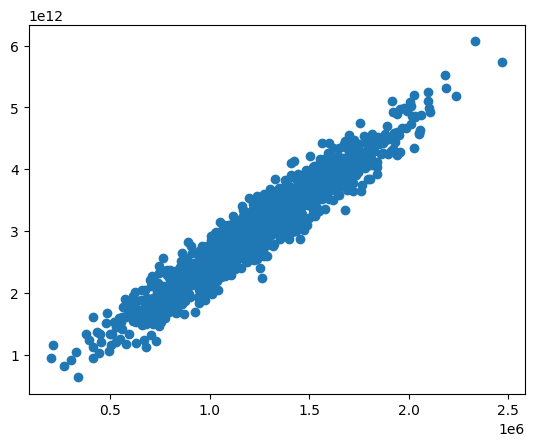

In [74]:
plt.scatter(y_test_original,y_pred_original)

Gráfico de dispersión predicho vs. real para el mejor SGDRegressor. Compara visualmente con el obtenido en el modelo clásico: la nube debería ser igual de compacta.

In [75]:
y_pred_original

array([[3.21003843e+12],
       [3.03422996e+12],
       [3.05268310e+12],
       ...,
       [3.09473448e+12],
       [2.64042932e+12],
       [3.08716929e+12]], shape=(1250, 1))

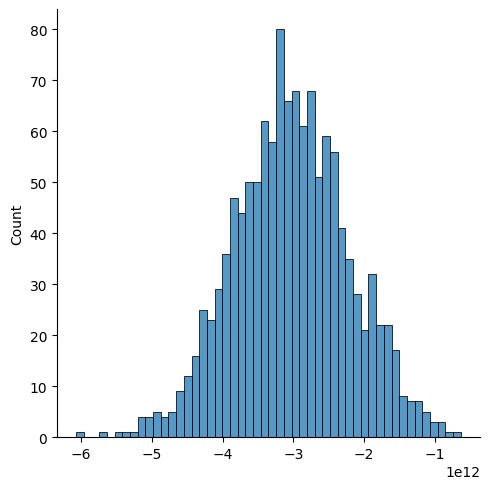

In [76]:
# histograma de residuales
sns.displot((y_test_original.reshape(-1)-y_pred_original.reshape(-1)),bins=50);

---
> **Conclusión Modelo 2 — SGDRegressor optimizado:**  
> Tras GridSearch, el SGDRegressor iguala el rendimiento del modelo clásico (R² ≈ 0.92) con la ventaja de escalar a datasets mucho más grandes y ofrecer control granular sobre regularización y tasa de aprendizaje.


#### 4. Modelo de Regresión Lasso y Ridge
Probamos ahora lasso y ridge, aunque con SGDRegressor se puede hacer indicando pentalty L1 o L2.

In [77]:
from sklearn.linear_model import Ridge, Lasso
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.metrics import mean_squared_error

# Ridge
ridge = Ridge(alpha=1.0)  # 'alpha' es el parámetro de regularización equivalente a 'lambda'
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))
r2_=r2_score(y_test, y_pred_ridge)
print("R2:", r2_)

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))
r2_=r2_score(y_test, y_pred_lasso)
print("R2:", r2_)

Ridge MSE: 10089716572.554762
R2: 0.9179914220241199
Lasso MSE: 10089010510.994362
R2: 0.9179971608478139


---
**Modelos regularizados: Ridge y Lasso**

| Modelo | Penalización | Efecto principal |
|---|---|---|
| **Ridge** (`L2`) | $\alpha \sum \beta_j^2$ | Reduce coeficientes pero no los anula. Bueno con multicolinealidad. |
| **Lasso** (`L1`) | $\alpha \sum |\beta_j|$ | Puede llevar coeficientes exactamente a 0 → **selección de variables automática**. |

El parámetro `alpha` controla la intensidad de la penalización: mayor alpha = más regularización = coeficientes más pequeños.  
Nota: se ha rehecho el `train_test_split` con `test_size=0.2` (80/20) en lugar del 60/40 anterior.


In [78]:
print(ridge.intercept_)
coeff_df = pd.DataFrame(ridge.coef_,X.columns,columns=['Coefficient'])
coeff_df

-2634603.83134852


,Coefficient
Avg. Area Income,21.652123
Avg. Area House Age,164624.137539
Avg. Area Number of Rooms,119585.966102
Avg. Area Number of Bedrooms,2454.734742
Area Population,15.270255


Los coeficientes de **Ridge** son similares a los de `LinearRegression` porque con alpha=1.0 la penalización es suave. Ninguno llega a cero.

In [79]:
print(lasso.intercept_)
coeff_df = pd.DataFrame(lasso.coef_,X.columns,columns=['Coefficient'])
coeff_df

-2635071.583212803


,Coefficient
Avg. Area Income,21.652206
Avg. Area House Age,164666.378500
Avg. Area Number of Rooms,119623.932897
Avg. Area Number of Bedrooms,2440.341894
Area Population,15.270313


Los coeficientes de **Lasso** pueden ser exactamente 0 si el alpha es suficientemente alto.  
Si `Avg. Area Number of Bedrooms` aparece con coeficiente 0, significa que Lasso ha considerado que esa variable **no aporta poder predictivo adicional** dado el resto.

#### 5. Resumen

* **LinearRegression()**    
    * Modelo clásico de regresión lineal ordinaria.
    * Minimiza el error cuadrático (MSE) sin penalizaciones.
    * Puede sobreajustarse si hay muchas variables o colinealidad.
    *  Útil cuando hay pocos predictores y no hay riesgo de sobreajuste.
* **SGDRegressor()**  
    * Usa descenso de gradiente estocástico (SGD) para ajustar los coeficientes.
    * Ideal para datasets muy grandes o en streaming.
    * Permite aplicar penalizaciones como 'l2' (Ridge), 'l1' (Lasso) o 'elasticnet'.
    * Es más sensible al escalado, así que suele ir acompañado de StandardScaler o MinMaxScaler
    * Úsalo cuando tienes gran cantidad de datos o quieres control granular sobre la optimización.  
* **Ridge(alpha=1.0)**  
    * Regresión lineal con penalización L2.
    * Penaliza coeficientes grandes sin eliminarlos.
    * Reduce el sobreajuste al suavizar la influencia de las variables.
    * Muy útil cuando hay multicolinealidad o muchas variables poco relevantes.  
* **Lasso(alpha=0.1)**
    * Regresión con penalización L1.
    * Puede llevar coeficientes exactamente a cero, haciendo selección de variables.
    * Cuanto mayor el alpha, más agresiva es la penalización.
    * Ideal si quieres reducir el número de variables y obtener un modelo más interpretable.  